In [4]:
mamba install pandas numpy matplotlib seaborn scipy



mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.381 seconds
All requested packages already installed.


Shape (rows, columns): (389002, 23)


/tmp/xpython_42/1615776479.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


trans_date_trans_time: 293627 unique values
merchant: 693 unique values
category: 14 unique values
first: 352 unique values
last: 481 unique values
gender: 2 unique values
street: 979 unique values
city: 890 unique values
state: 51 unique values
job: 492 unique values
dob: 964 unique values
trans_num: 389002 unique values


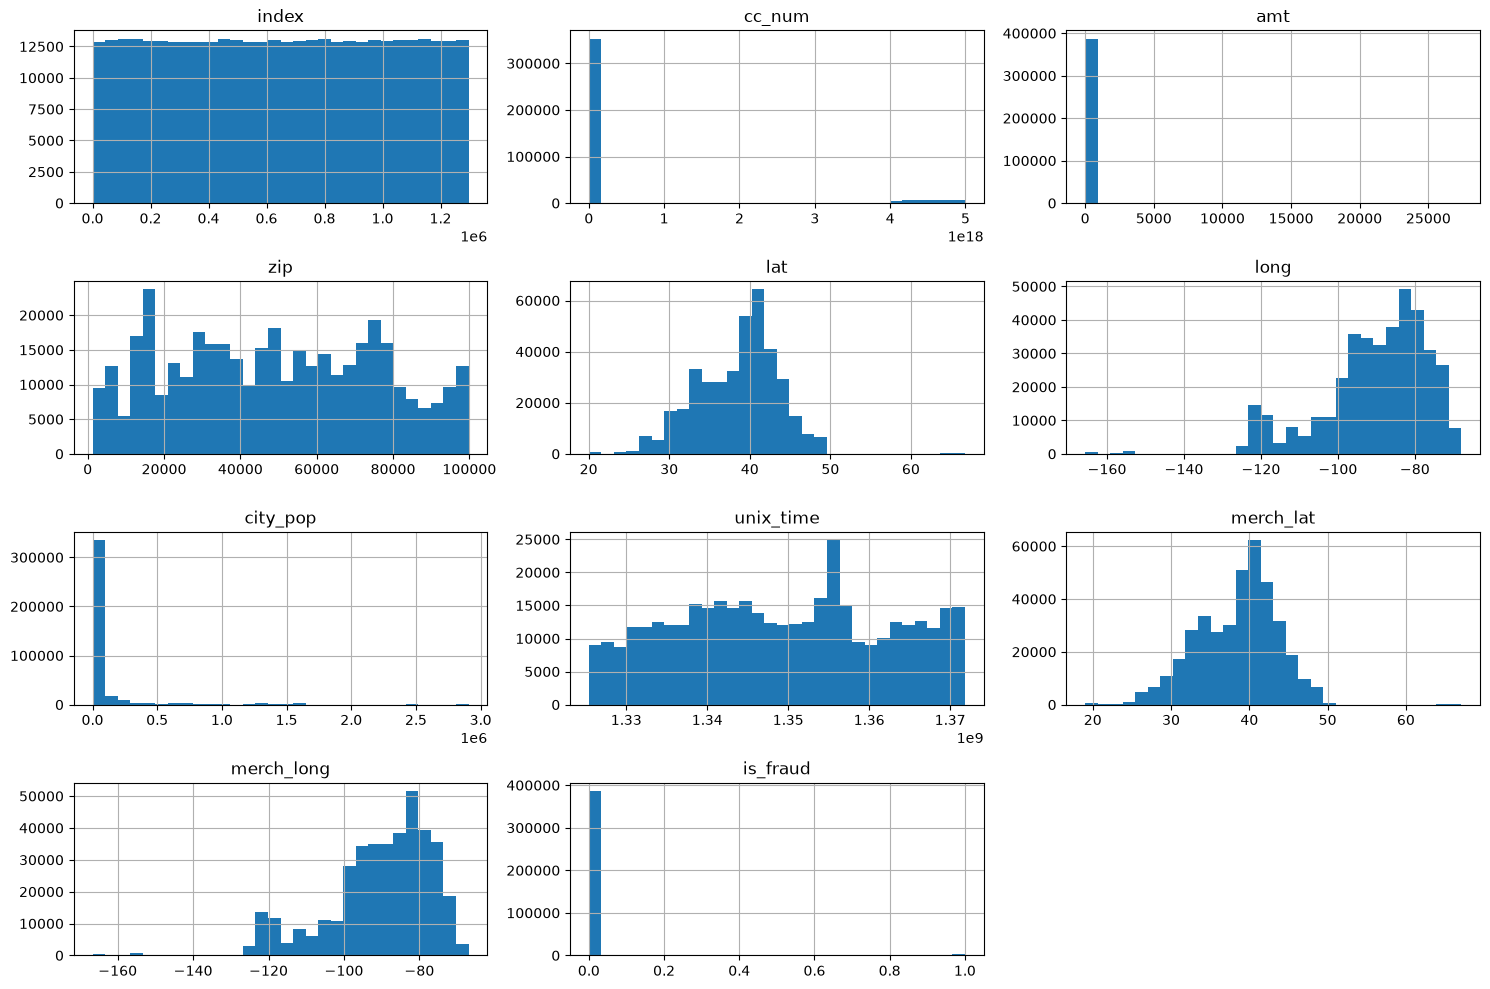

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
              index        cc_num            amt            zip  \
count  3.890020e+05  3.890020e+05  389002.000000  389002.000000   
mean   6.485205e+05  4.191512e+17      70.442148   48818.064295   
std    3.745744e+05  1.311579e+18     162.203915   26879.383224   
min    1.100000e+01  6.041621e+10       1.000000    1257.000000   
25%    3.241842e+05  1.800429e+14       9.660000   26237.000000   
50%    6.486485e+05  3.521417e+15      47.570000   48174.000000   
75%    9.735032e+05  4.642255e+15      83.077500   72011.000000   
max    1.296674e+06  4.992346e+18   27390.120000   99783.000000   

                 lat           long      city_pop     unix_time  \
count  389002.000000  389002.000000  3.890020e+05  3.890020e+05   
mean       38.533121     -90.237664  8.868084e+04  1.349251e+09   
std         5.074596      13.745855  3.012101e+05  1.285085e+07   
min        20.027100    -165.672300  2.300000e+01  1.325376e+09 

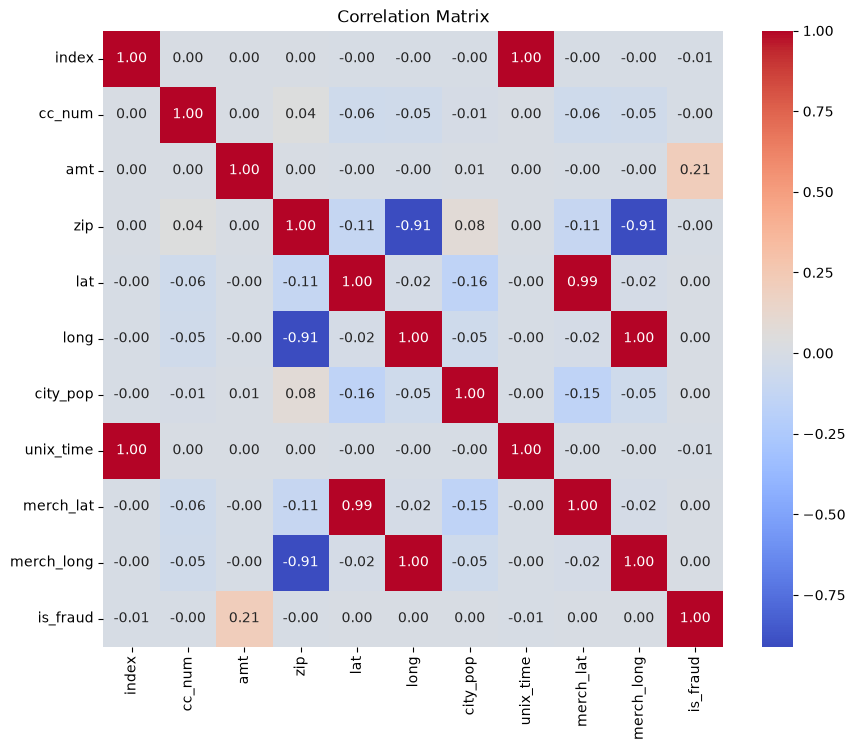

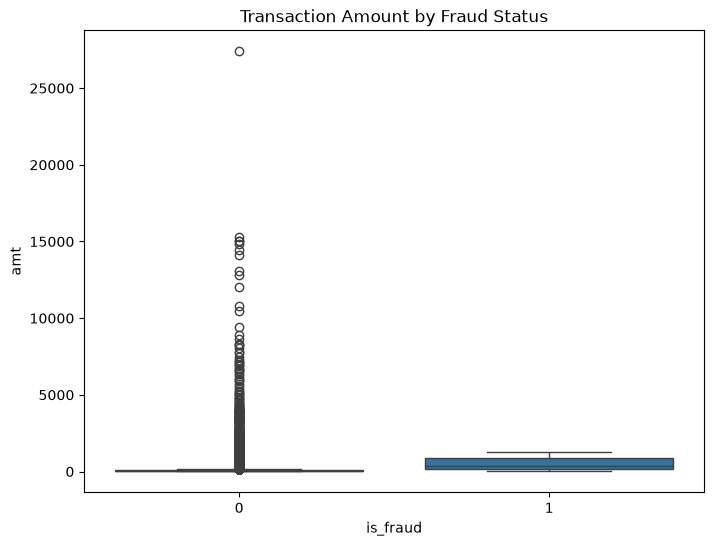

             count        mean         std   min       25%      50%       75%  \
is_fraud                                                                        
0         386750.0   67.834157  156.227752  1.00    9.6200   47.330   82.5000   
1           2252.0  518.328677  389.127281  1.18  147.8825  365.285  888.3425   

               max  
is_fraud            
0         27390.12  
1          1294.83  
amt outliers: 20377
city_pop outliers: 72813


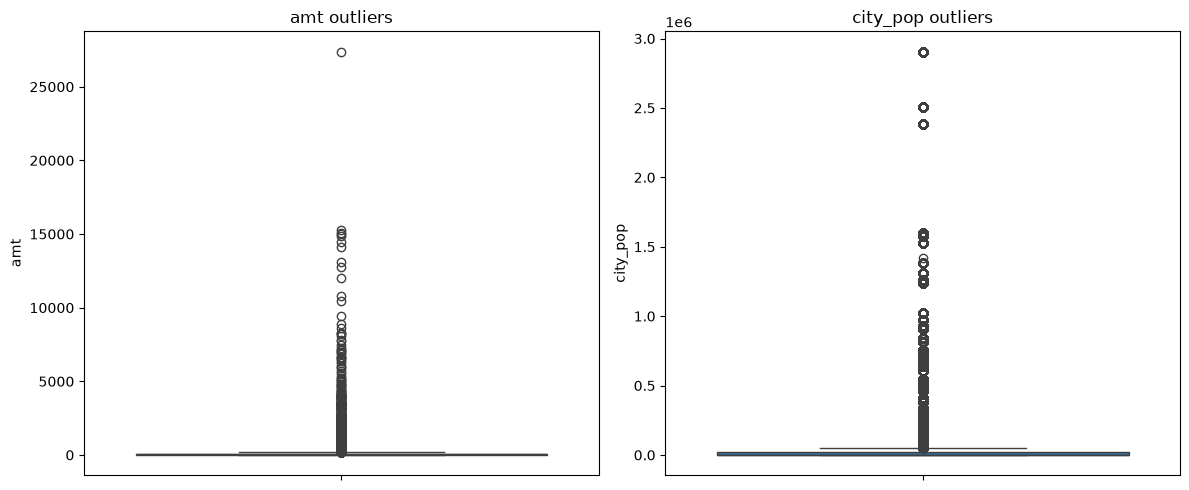

/tmp/xpython_42/1615776479.py:68: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])


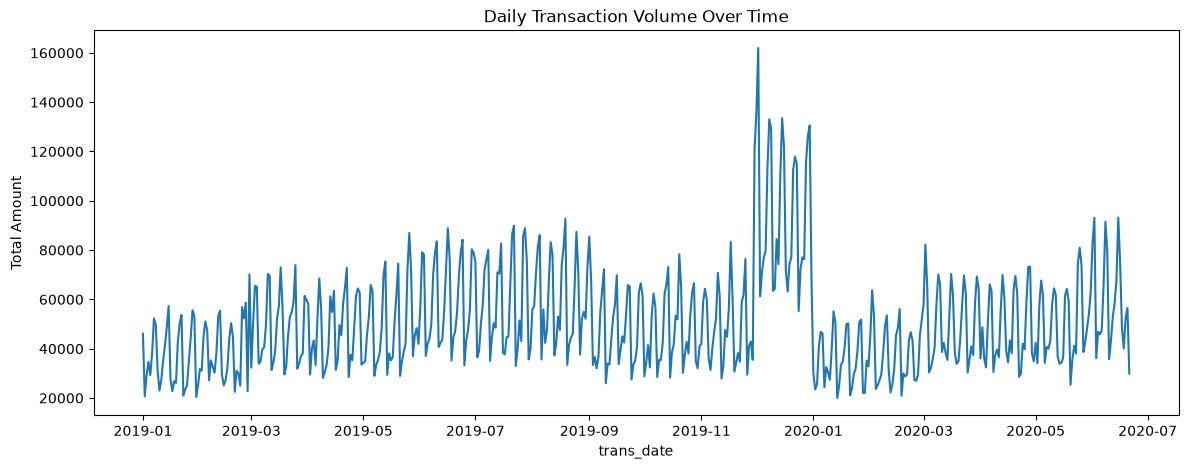

category
shopping_net      0.016317
misc_net          0.015017
grocery_pos       0.014090
shopping_pos      0.007226
gas_transport     0.004870
travel            0.003445
misc_pos          0.003202
grocery_net       0.002889
personal_care     0.002776
entertainment     0.002418
kids_pets         0.002182
home              0.001762
food_dining       0.001552
health_fitness    0.001516
Name: is_fraud, dtype: float64


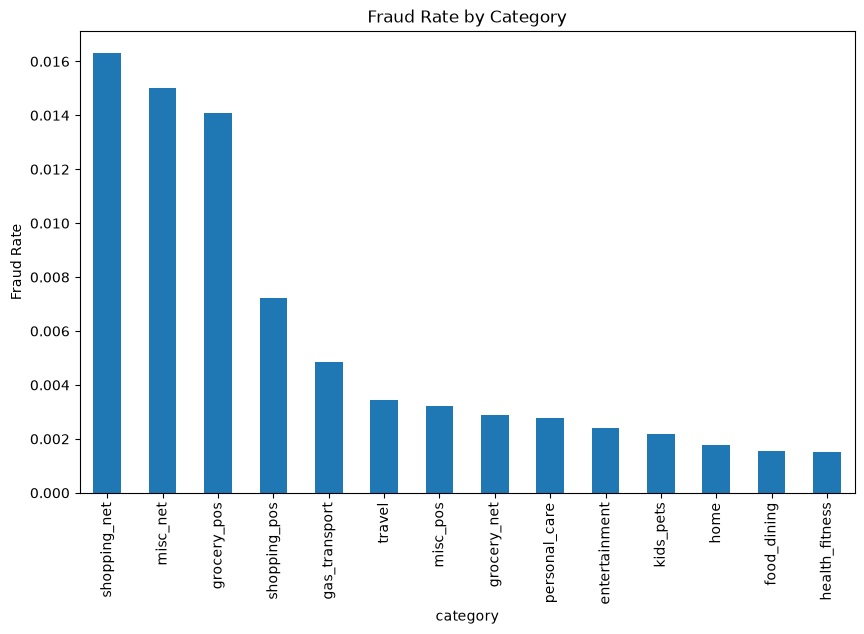

Negative amounts: 0
Zero amounts: 0
Future dates: 0
Duplicate rows: 0
Duplicate trans_num: 0


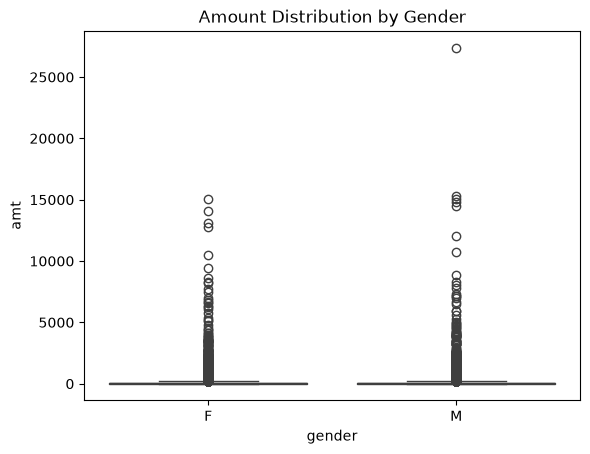

is_fraud      1.000000
amt           0.210706
lat           0.002643
merch_lat     0.002406
long          0.001376
merch_long    0.001351
city_pop      0.001176
zip          -0.001220
cc_num       -0.001280
index        -0.006121
unix_time    -0.006562
Name: is_fraud, dtype: float64


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('notebooks/cc_data.csv')

# 1. Dimensions of the dataset
print("Shape (rows, columns):", df.shape)

# 2. Unique values per categorical variable
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# 3. Distribution of numerical variables
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

# 4. Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_summary[missing_summary['missing_count'] > 0])
# Handling: drop columns with very high missingness, impute (median for numeric,
# mode for categorical) for moderate missingness, drop rows only if missingness is trivial.

# 5. Summary statistics for numerical variables
print(df[numerical_cols].describe())

# 6. Correlation between numerical variables
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# 7. Distribution of amt across is_fraud categories
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title('Transaction Amount by Fraud Status')
plt.show()

print(df.groupby('is_fraud')['amt'].describe())

# 8. Outliers in city_pop and amt (IQR method)
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

print("amt outliers:", len(iqr_outliers(df['amt'])))
print("city_pop outliers:", len(iqr_outliers(df['city_pop'])))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['amt'], ax=axes[0]).set_title('amt outliers')
sns.boxplot(y=df['city_pop'], ax=axes[1]).set_title('city_pop outliers')
plt.tight_layout()
plt.show()

# 9. Trends over time
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_date'] = df['trans_date_trans_time'].dt.date
daily_amt = df.groupby('trans_date')['amt'].sum()
plt.figure(figsize=(14, 5))
daily_amt.plot()
plt.title('Daily Transaction Volume Over Time')
plt.ylabel('Total Amount')
plt.show()

# 10. Target variable (is_fraud) distribution across categories
fraud_by_category = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
print(fraud_by_category)

plt.figure(figsize=(10, 6))
fraud_by_category.plot(kind='bar')
plt.title('Fraud Rate by Category')
plt.ylabel('Fraud Rate')
plt.show()

# 11. Unusual/unexpected values
print("Negative amounts:", (df['amt'] < 0).sum())
print("Zero amounts:", (df['amt'] == 0).sum())
print("Future dates:", (df['trans_date_trans_time'] > pd.Timestamp.now()).sum())

# 12. Potential data entry errors
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate trans_num:", df['trans_num'].duplicated().sum())

# 13. Distribution of numerical variables across groups (example: amt by gender)
sns.boxplot(x='gender', y='amt', data=df)
plt.title('Amount Distribution by Gender')
plt.show()

# 14. Top factors influencing is_fraud (correlation-based, quick view)
fraud_corr = df[numerical_cols].corr()['is_fraud'].sort_values(ascending=False)
print(fraud_corr)